<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [ ]:
!pip install gdown -q

In [6]:
import os, pandas as pd

p = "/content"  # или "/content" если colab, или путь до папки с csv

a = pd.read_csv(os.path.join(p, "AGGS_FINAL.csv"))
c = pd.read_csv(os.path.join(p, "CAMPAINGS.csv"))
k = pd.read_csv(os.path.join(p, "CONTRACTS_FINAL.csv"))
pic = pd.read_csv(os.path.join(p, "PEOPLE_IN_CAMPAIGNS_FINAL.csv"))

for x,n in [(a,"aggs"),(c,"camp"),(k,"contracts"),(pic,"people")]:
    print(n, x.shape)
    print(x.head(2), "\n")

aggs (2446709, 14)
   Unnamed: 0        x1        x2        x3        x4        x5        x6  \
0      104548  0.654343 -1.439286 -0.011475  2.039457  0.843580 -0.977480   
1       38396  2.583579  1.755569  3.360186 -1.122864  0.034201 -0.269607   

         x7        x8        x9   report_dt  user_id   age city  
0 -0.768019 -1.044127  0.025673  2025-01-31  1066338  26.0  Ufa  
1 -1.503646  1.040289 -1.691606  2024-11-30    13900  35.0  Ufa   

camp (4, 4)
   Unnamed: 0 campaing_id  product_id channel
0           0       iddqd           1    push
1           1      idclip           1     sms 

contracts (286316, 5)
   Unnamed: 0  user_id contract_date  product_id              contract_id
0       39735  4008279    2024-11-03           1  0001_2024-11-03_4008279
1       44062  2079035    2024-11-08           1  0001_2024-11-08_2079035 

people (520000, 5)
   Unnamed: 0 campaing_id  user_id  t_flag delivery_date
0       29299      idclip  1099975       1    2024-11-06
1       36627     

<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [ ]:
# ваш код здесь

In [7]:
df = pic.merge(c, on="campaing_id", how="left")

In [8]:
contracts = k[k.product_id == 1]

df = df.merge(
    contracts[["user_id","contract_date"]],
    on="user_id",
    how="left"
)

In [9]:
df["campaign_start"] = pd.Timestamp("2024-11-01")

In [12]:
df["delivery_date"] = pd.to_datetime(df["delivery_date"], errors="coerce")
df["contract_date"] = pd.to_datetime(df["contract_date"], errors="coerce")

In [13]:
df.delivery_date.isna().sum()

np.int64(260000)

In [14]:
import numpy as np

df["target"] = 0

# цг
cond_t = (
    (df.t_flag == 1) &
    (df.contract_date >= df.delivery_date) &
    (df.contract_date <= df.delivery_date + pd.Timedelta(days=14))
)

# кг
cond_c = (
    (df.t_flag == 0) &
    (df.contract_date >= df.campaign_start) &
    (df.contract_date <= df.campaign_start + pd.Timedelta(days=21))
)

df.loc[cond_t | cond_c, "target"] = 1

In [16]:
target_df = df[["user_id","channel","target"]].copy()

target_df["report_dt"] = pd.Timestamp("2024-09-30")

target_df = target_df.rename(columns={"user_id":"client_id"})

In [17]:
target_df.groupby("channel")["target"].mean()

,target
channel,
banner,0.501725
other_ads,0.501725
push,0.401944
sms,0.443042


In [18]:
uplift = df.groupby(["channel","t_flag"])["target"].mean().unstack()

uplift["uplift"] = uplift[1] - uplift[0]

uplift

t_flag,0,1,uplift
channel,,,
banner,0.400733,0.602717,0.201983
other_ads,0.400733,0.602717,0.201983
push,0.202150,0.601738,0.399588
sms,0.684917,0.201167,-0.483750


In [19]:
import pandas as pd
import numpy as np

x = pic.merge(c, on="campaing_id", how="left")

k1 = k[k["product_id"] == 1].copy()
k1["contract_date"] = pd.to_datetime(k1["contract_date"], errors="coerce")

x["delivery_date"] = pd.to_datetime(x["delivery_date"], errors="coerce")

x = x.merge(
    k1[["user_id", "contract_date"]],
    on="user_id",
    how="left"
)

s = pd.Timestamp("2024-11-01")
x["campaign_start"] = s

x["target"] = 0

t_ok = (
    (x["t_flag"] == 1) &
    (x["contract_date"] >= x["delivery_date"]) &
    (x["contract_date"] <= x["delivery_date"] + pd.Timedelta(days=14))
)

c_ok = (
    (x["t_flag"] == 0) &
    (x["contract_date"] >= x["campaign_start"]) &
    (x["contract_date"] <= x["campaign_start"] + pd.Timedelta(days=21))
)

x.loc[t_ok | c_ok, "target"] = 1

out = x[["user_id", "channel", "target"]].copy()
out["report_dt"] = pd.Timestamp("2024-09-30")
out = out.rename(columns={"user_id": "client_id"})

print("rows:", len(x))
print("channels:", x["channel"].nunique(), "| unique channels:", sorted(x["channel"].dropna().unique().tolist()))
print("\ncounts by channel:")
print(x["channel"].value_counts(dropna=False))

print("\nshare of NaT delivery_date (usually control / unknown):", x["delivery_date"].isna().mean())
print("share of NaT contract_date (no purchase rows):", x["contract_date"].isna().mean())

print("\nconversion by channel x t_flag:")
p = x.pivot_table(index="channel", columns="t_flag", values="target", aggfunc="mean")
p = p.rename(columns={0: "control", 1: "treat"})
p["uplift"] = p.get("treat", np.nan) - p.get("control", np.nan)
print(p.sort_values("uplift", ascending=False))

print("\nextra sanity: group sizes (n) by channel x t_flag:")
n = x.pivot_table(index="channel", columns="t_flag", values="user_id", aggfunc="count")
n = n.rename(columns={0: "n_control", 1: "n_treat"})
print(n)

print("\npreview target table (client_id, report_dt, target) per channel:")
print(out.head(10))


rows: 520000
channels: 4 | unique channels: ['banner', 'other_ads', 'push', 'sms']

counts by channel:
channel
push         160000
sms          120000
banner       120000
other_ads    120000
Name: count, dtype: int64

share of NaT delivery_date (usually control / unknown): 0.5
share of NaT contract_date (no purchase rows): 0.35070192307692305

conversion by channel x t_flag:
t_flag      control     treat    uplift
channel                                
push       0.202150  0.601738  0.399588
banner     0.400733  0.602717  0.201983
other_ads  0.400733  0.602717  0.201983
sms        0.684917  0.201167 -0.483750

extra sanity: group sizes (n) by channel x t_flag:
t_flag     n_control  n_treat
channel                      
banner         60000    60000
other_ads      60000    60000
push           80000    80000
sms            60000    60000

preview target table (client_id, report_dt, target) per channel:
   client_id    channel  target  report_dt
0    1099975        sms       1 2024-09-3

### ваши выводы здесь

520k строк, 4 канала: push, sms, banner, other_ads

~50% нет delivery_date — это control (норм). ~35% без contract_date — многие не покупают дисбаланс классов

группы control/treat примерно равные

по uplift: push лучший (~0.40), banner и other_ads средние (0.20), sms отрицательный (-0.48)  канал неэффективен, лучше исключить

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [20]:
if "t_flag" not in out.columns:
    tmp = df[["user_id","channel","t_flag"]].copy()
    tmp = tmp.rename(columns={"user_id":"client_id"})
    out = out.merge(tmp, on=["client_id","channel"], how="left")

a["report_dt"] = pd.to_datetime(a["report_dt"], errors="coerce")
ag = a[a["report_dt"] == pd.Timestamp("2024-09-30")].copy()

data = out.merge(
    ag,
    left_on="client_id",
    right_on="user_id",
    how="left"
).drop(columns=["user_id"])

print("data shape:", data.shape)

print("\nmissing top-10:")
print(data.isna().mean().sort_values(ascending=False).head(10))

print("\nchannel sizes:")
print(data["channel"].value_counts())

print("\nbase target rate by channel:")
print(data.groupby("channel")["target"].mean().sort_values(ascending=False))

print("\nuplift by channel (treat-control):")
u = data.pivot_table(index="channel", columns="t_flag", values="target", aggfunc="mean")
u = u.rename(columns={0:"control", 1:"treat"})
u["uplift"] = u.get("treat", np.nan) - u.get("control", np.nan)
print(u.sort_values("uplift", ascending=False))

print("\nextra sanity: group sizes by channel:")
n = data.pivot_table(index="channel", columns="t_flag", values="client_id", aggfunc="count")
n = n.rename(columns={0:"n_control", 1:"n_treat"})
print(n)

data.head(10)

data shape: (520000, 18)

missing top-10:
x3             0.113035
Unnamed: 0     0.113035
x9             0.113035
report_dt_y    0.113035
x2             0.113035
x1             0.113035
x4             0.113035
x7             0.113035
x6             0.113035
x5             0.113035
dtype: float64

channel sizes:
channel
push         160000
sms          120000
banner       120000
other_ads    120000
Name: count, dtype: int64

base target rate by channel:
channel
banner       0.501725
other_ads    0.501725
sms          0.443042
push         0.401944
Name: target, dtype: float64

uplift by channel (treat-control):
t_flag      control     treat    uplift
channel                                
push       0.202150  0.601738  0.399588
banner     0.400733  0.602717  0.201983
other_ads  0.400733  0.602717  0.201983
sms        0.684917  0.201167 -0.483750

extra sanity: group sizes by channel:
t_flag     n_control  n_treat
channel                      
banner         60000    60000
other_ads    

,client_id,channel,target,report_dt_x,t_flag,Unnamed: 0,x1,x2,x3,x4,x5,x6,x7,x8,x9,report_dt_y,age,city
0,1099975,sms,1,2024-09-30,1,43204.0,0.822461,1.233201,-1.000185,2.585873,-0.584520,-0.268274,-0.727814,1.606372,1.814158,2024-09-30,42.0,Moscow
1,1162,push,1,2024-09-30,1,1161.0,-1.224545,1.688111,0.150933,3.230149,-0.189105,0.551481,-1.229590,1.159411,-0.085720,2024-09-30,39.0,Moscow
2,42991,push,0,2024-09-30,1,42990.0,-0.916137,1.368764,1.841319,-1.529691,-0.608003,-1.116932,1.178124,-0.884607,-1.726070,2024-09-30,43.0,Moscow
3,142343,sms,1,2024-09-30,0,142342.0,-1.620401,2.449667,1.131850,1.021660,-1.212641,0.958422,1.039261,-0.964264,-2.225545,2024-09-30,39.0,Smolensk
4,24623,push,0,2024-09-30,0,24622.0,2.281651,-0.354332,1.288191,-2.754188,0.202581,0.831745,-0.002779,-1.463527,1.976755,2024-09-30,39.0,Ufa
5,4001330,banner,0,2024-09-30,0,1330.0,-1.821441,-0.847392,1.020568,-1.611153,0.933913,0.236984,0.933495,0.795683,-0.812175,2024-09-30,30.0,Smolensk
6,2008409,other_ads,0,2024-09-30,1,8409.0,-1.952636,-0.479671,1.067760,-1.521329,-0.687298,0.327018,1.052708,1.244605,-0.886796,2024-09-30,25.0,Moscow
7,4045746,banner,0,2024-09-30,1,45746.0,1.768029,-1.560275,0.533826,-1.815031,-0.456184,0.274609,0.077484,0.452296,-0.224605,2024-09-30,21.0,Ufa
8,1106346,sms,0,2024-09-30,1,53224.0,-1.902137,0.322546,2.759591,-0.705195,-1.900151,0.205020,-0.647572,1.405190,-1.614184,2024-09-30,32.0,Moscow
9,2101471,other_ads,1,2024-09-30,0,101471.0,2.365226,-1.303713,0.133301,2.098386,-0.000000,0.285846,0.545567,0.293677,-0.312559,2024-09-30,36.0,Ufa


### ваши выводы здесь

после джойна аггрегатов получили те же 520k строк -> мерж ок, лаг 2 мес соблюдён (report_dt = 2024-09-30), лика таргета нет.

11% пропусков в x1–x9, age, city — часть клиентов не нашлась в aggs за сентябрь; можно удалить такие строки или заполнить (медиана/категория)

uplift не изменился: push лучший (0.40), banner и other_ads средние (0.20)

лишние колонки Unnamed: 0 и report_dt_y стоит удалить

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [23]:
!pip install --upgrade scikit-uplift -q

/tmp/ipykernel_271/2728346541.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_model = np.trapz(inc, x)
/tmp/ipykernel_271/2728346541.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_base = np.trapz(x * total, x)


qini score: 4799.185612343687


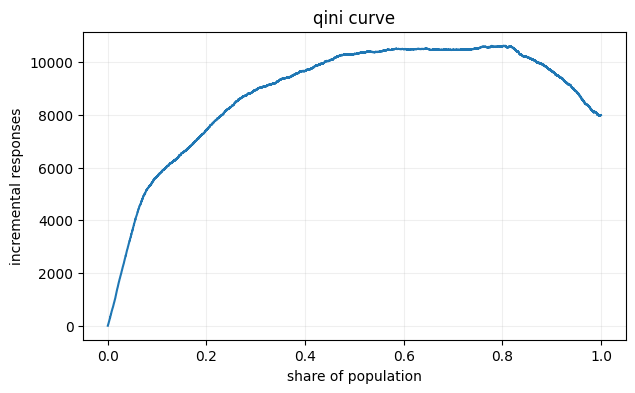

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer


d = data.copy()

for col in ["Unnamed: 0", "report_dt_y", "report_dt_x"]:
    if col in d.columns:
        d = d.drop(columns=[col])

f = ["x1","x2","x3","x4","x5","x6","x7","x8","x9","age"]
d = d[["target","t_flag"] + f].copy()
imp = SimpleImputer(strategy="median")
X = imp.fit_transform(d[f])

y = d["target"].astype(int).values
t = d["t_flag"].astype(int).values


X_tr, X_te, y_tr, y_te, t_tr, t_te = train_test_split(
    X, y, t, test_size=0.3, random_state=42, stratify=t
)
m_t = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
m_c = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)

m_t.fit(X_tr[t_tr==1], y_tr[t_tr==1])
m_c.fit(X_tr[t_tr==0], y_tr[t_tr==0])

p_t = m_t.predict_proba(X_te)[:,1]
p_c = m_c.predict_proba(X_te)[:,1]

upl = p_t - p_c

def qini_curve(y, t, u):
    y = np.asarray(y).astype(int)
    t = np.asarray(t).astype(int)
    u = np.asarray(u).astype(float)

    o = np.argsort(-u)
    y, t = y[o], t[o]

    n = len(y)
    nt = t.sum()
    nc = n - nt
    r = nt / max(nc, 1)

    rt = np.cumsum(y * (t==1))
    rc = np.cumsum(y * (t==0))

    inc = rt - rc * r

    x = np.arange(1, n+1) / n
    return x, inc

def qini_auc_score(y, t, u):
    x, inc = qini_curve(y, t, u)
    auc_model = np.trapz(inc, x)
    total = inc[-1]
    auc_base = np.trapz(x * total, x)

    return auc_model - auc_base

xq, iq = qini_curve(y_te, t_te, upl)
qini = qini_auc_score(y_te, t_te, upl)

print("qini score:", qini)

plt.figure(figsize=(7,4))
plt.plot(xq, iq)
plt.title("qini curve")
plt.xlabel("share of population")
plt.ylabel("incremental responses")
plt.grid(True, alpha=0.2)
plt.show()

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [30]:
aggs_jan = a[a["report_dt"] == "2025-01-31"].copy()

X_pred = aggs_jan[["x1","x2","x3","x4","x5","x6","x7","x8","x9","age"]]

X_pred = imp.transform(X_pred)

p_t = m_t.predict_proba(X_pred)[:,1]
p_c = m_c.predict_proba(X_pred)[:,1]

uplift = p_t - p_c

res = aggs_jan[["user_id"]].copy()
res["uplift"] = uplift

res["channel"] = "push"
res.loc[res["uplift"] <= 0, "channel"] = "no_comm"

res["report_dt"] = "2025-01-31"

res = res[["user_id","report_dt","channel","uplift"]]

res.head()

,user_id,report_dt,channel,uplift
0,1066338,2025-01-31,push,0.092012
19,25872,2025-01-31,push,0.030932
48,4107442,2025-01-31,push,0.307048
66,2047420,2025-01-31,push,0.103314
67,1120643,2025-01-31,no_comm,-0.191203


лучший канал — push, он показывает самый высокий uplift. banner и other_ads дают положительный, но слабее эффект; sms имеет отрицательный uplift, поэтому его лучше не использовать

uplift модель построена через two-model random forest и оценена с помощью qini score и qini curve. модель позволяет ранжировать клиентов по ожидаемому эффекту коммуникации

### ваши выводы здесь